# Inspect temporal Leiden communities for the first Bf_DTA_anes mouse

This notebook reruns temporal Leiden community detection on the first scan found in:

`outputs/window_connectivity/Bf_DTA_anes/FD_cut30frames_bandpass0.01-0.1_cut30edges_mot6_CSF_smooth6/sub-ag230908/sub-ag230908a`

The analysis uses 20 independent Leiden runs with `gamma = 0.35` and `omega = 0.25`.

Leiden's integer community labels are arbitrary. Community `0` in one run is not necessarily the same as community `0` in another run. We therefore interpret the result through a **co-assignment matrix**: for every pair of ROIs, we calculate the proportion of runs and windows in which they were assigned to the same community. A six-community consensus partition is then obtained from this label-invariant matrix and visualized with Toyplot.

In [1]:
import importlib.util
import multiprocessing
import sys
from collections import defaultdict
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path

import leidenalg as la
import numpy as np
import pandas as pd
import toyplot
import toyplot.color
import toyplot.data
import toyplot.svg
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import squareform

print(f"Toyplot version: {toyplot.__version__}")

Toyplot version: 2.1.0


## Configuration

All available windows from the first scan in the requested mouse folder are used. Fixed random seeds make the 20-run analysis reproducible.

In [2]:
WORKING_DIR = Path.cwd().resolve()
ROOT = WORKING_DIR.parent if WORKING_DIR.name == "scripts" else WORKING_DIR

WINDOW_DIR = (
    ROOT
    / "outputs"
    / "window_connectivity"
    / "Bf_DTA_anes"
    / "FD_cut30frames_bandpass0.01-0.1_cut30edges_mot6_CSF_smooth6"
    / "sub-ag230908"
    / "sub-ag230908a"
)

GAMMA = 0.35
OMEGA = 0.25
N_RUNS = 20
RUN_WORKERS = min(8, N_RUNS)
RANDOM_SEED = 20260615
CONSENSUS_COMMUNITIES = 6

OUTPUT_DIR = ROOT / "outputs" / "community_interpretation" / "sub-ag230908a_gamma-0.35_omega-0.25"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert WINDOW_DIR.is_dir(), f"Missing input directory: {WINDOW_DIR}"
WINDOW_DIR

PosixPath('/home/luca.galli-1/neuro3ducate/mouse-fmri-dyncomm/outputs/window_connectivity/Bf_DTA_anes/FD_cut30frames_bandpass0.01-0.1_cut30edges_mot6_CSF_smooth6/sub-ag230908/sub-ag230908a')

## Select the first scan

Files are sorted by window number. The scan prefix of the first file determines the scan analyzed below.

In [3]:
all_window_paths = sorted(WINDOW_DIR.glob("*_window_*.csv"))
assert all_window_paths, f"No connectivity windows found in {WINDOW_DIR}"

first_stem = all_window_paths[0].stem
SCAN_ID = first_stem.rsplit("_window_", 1)[0]
window_paths = [
    path for path in all_window_paths
    if path.stem.rsplit("_window_", 1)[0] == SCAN_ID
]

print(f"Scan: {SCAN_ID}")
print(f"Windows: {len(window_paths)}")
print(f"First window: {window_paths[0].name}")
print(f"Last window:  {window_paths[-1].name}")

Scan: sub-ag230908a_EXP_bold_parcellated
Windows: 650
First window: sub-ag230908a_EXP_bold_parcellated_window_0008.csv
Last window:  sub-ag230908a_EXP_bold_parcellated_window_0671.csv


## Load the temporal connectivity graphs

The notebook reuses the graph construction from `04_run_community_detection.py`: one vertex per ROI, positive Pearson correlations as weighted edges, and a zero diagonal.

In [4]:
scripts_dir = ROOT / "scripts"
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

spec = importlib.util.spec_from_file_location(
    "community_detection_04",
    scripts_dir / "04_run_community_detection.py",
)
cd04 = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = cd04
spec.loader.exec_module(cd04)

graphs = []
roi_names = None
window_ids = []

for path in window_paths:
    frame = cd04.read_window(str(path))
    current_rois = list(frame.columns)
    if roi_names is None:
        roi_names = current_rois
    else:
        assert current_rois == roi_names, f"ROI order changed in {path}"
    graphs.append(cd04.build_igraph(frame))
    window_ids.append(int(path.stem.rsplit("_window_", 1)[1]))

print(f"Loaded {len(graphs)} graphs with {len(roi_names)} ROIs each")
print("ROI order:", ", ".join(roi_names))

Loaded 650 graphs with 16 ROIs each
ROI order: DMNa, DMNp, SAL, OLF, STR, AUD, VIS, TH, MOp, SSp, SSs, HCa, SUB, CTXsp, BF, HY


## Run temporal Leiden 20 times

Each run returns a membership matrix with shape `windows x ROIs`. Runs are parallelized across eight worker processes. The saved random seeds allow the result to be reproduced exactly.

In [5]:
_WORKER_GRAPHS = None


def _initialize_worker(worker_graphs):
    global _WORKER_GRAPHS
    _WORKER_GRAPHS = worker_graphs


def _run_single_leiden(seed):
    memberships, improvement = la.find_partition_temporal(
        _WORKER_GRAPHS,
        la.CPMVertexPartition,
        interslice_weight=OMEGA,
        vertex_id_attr="id",
        weight_attr="weight",
        resolution_parameter=GAMMA,
        seed=int(seed),
    )
    return np.asarray(memberships, dtype=np.int32), float(improvement)

In [6]:
seed_generator = np.random.default_rng(RANDOM_SEED)
leiden_seeds = seed_generator.integers(
    0, 2**31 - 1, size=N_RUNS, dtype=np.int64
).tolist()

run_results = [None] * N_RUNS
mp_context = multiprocessing.get_context("fork")

with ProcessPoolExecutor(
    max_workers=RUN_WORKERS,
    mp_context=mp_context,
    initializer=_initialize_worker,
    initargs=(graphs,),
) as executor:
    futures = {
        executor.submit(_run_single_leiden, seed): index
        for index, seed in enumerate(leiden_seeds)
    }
    for completed, future in enumerate(as_completed(futures), start=1):
        index = futures[future]
        run_results[index] = future.result()
        print(f"Completed Leiden run {completed:02d}/{N_RUNS}")

memberships = np.stack([result[0] for result in run_results])
quality_improvements = np.asarray([result[1] for result in run_results])

expected_shape = (N_RUNS, len(graphs), len(roi_names))
assert memberships.shape == expected_shape, (memberships.shape, expected_shape)
np.savez_compressed(
    OUTPUT_DIR / "leiden_memberships.npz",
    memberships=memberships,
    seeds=np.asarray(leiden_seeds),
    window_ids=np.asarray(window_ids),
    roi_names=np.asarray(roi_names),
    gamma=GAMMA,
    omega=OMEGA,
)
print(f"Membership array: {memberships.shape}")
print(f"Mean Leiden quality improvement: {quality_improvements.mean():.3f}")

Completed Leiden run 01/20


Completed Leiden run 02/20


Completed Leiden run 03/20


Completed Leiden run 04/20


Completed Leiden run 05/20


...

Completed Leiden run 16/20


Completed Leiden run 17/20


Completed Leiden run 18/20


Completed Leiden run 19/20


Completed Leiden run 20/20
Membership array: (20, 650, 16)
Mean Leiden quality improvement: 9876.378


## Label-invariant community summary

First, inspect the natural number of communities returned per window. Then calculate the ROI co-assignment matrix across all 20 runs and all windows.

In [7]:
community_counts = np.asarray([
    [len(np.unique(window_membership)) for window_membership in run]
    for run in memberships
])

count_summary = pd.Series(community_counts.ravel(), name="communities").describe()
display(count_summary.to_frame())

coassignment = np.mean(
    memberships[:, :, :, None] == memberships[:, :, None, :],
    axis=(0, 1),
)
coassignment_df = pd.DataFrame(coassignment, index=roi_names, columns=roi_names)
display(coassignment_df.round(3))

coassignment_df.to_csv(OUTPUT_DIR / "roi_coassignment.csv")

,communities
count,13000.000000
mean,6.317923
std,1.126748
min,2.000000
25%,6.000000
50%,6.000000
75%,7.000000
max,10.000000


,DMNa,DMNp,SAL,OLF,STR,AUD,VIS,TH,MOp,SSp,SSs,HCa,SUB,CTXsp,BF,HY
DMNa,1.000,0.125,0.275,0.178,0.136,0.114,0.073,0.114,0.252,0.158,0.170,0.115,0.071,0.078,0.183,0.124
DMNp,0.125,1.000,0.140,0.145,0.167,0.197,0.374,0.170,0.111,0.148,0.115,0.148,0.216,0.194,0.158,0.106
SAL,0.275,0.140,1.000,0.319,0.323,0.123,0.049,0.084,0.214,0.169,0.167,0.141,0.097,0.205,0.155,0.069
OLF,0.178,0.145,0.319,1.000,0.239,0.210,0.074,0.119,0.110,0.061,0.202,0.154,0.126,0.446,0.250,0.163
STR,0.136,0.167,0.323,0.239,1.000,0.198,0.136,0.080,0.200,0.193,0.209,0.185,0.165,0.210,0.380,0.092
AUD,0.114,0.197,0.123,0.210,0.198,1.000,0.211,0.130,0.134,0.153,0.213,0.230,0.189,0.172,0.229,0.081
VIS,0.073,0.374,0.049,0.074,0.136,0.211,1.000,0.172,0.073,0.143,0.132,0.223,0.322,0.206,0.099,0.139
TH,0.114,0.170,0.084,0.119,0.080,0.130,0.172,1.000,0.195,0.156,0.163,0.195,0.183,0.125,0.106,0.253
MOp,0.252,0.111,0.214,0.110,0.200,0.134,0.073,0.195,1.000,0.298,0.173,0.151,0.065,0.111,0.133,0.092
SSp,0.158,0.148,0.169,0.061,0.193,0.153,0.143,0.156,0.298,1.000,0.226,0.197,0.150,0.065,0.121,0.160


## Six-community consensus and expected-network comparison

Average-linkage clustering is applied to `1 - coassignment` and cut at six communities. The integer consensus IDs below are still arbitrary, so each discovered group is matched to the expected functional network with the highest globally consistent Jaccard overlap.

In [8]:
distance = 1.0 - coassignment
np.fill_diagonal(distance, 0.0)
condensed_distance = squareform((distance + distance.T) / 2.0, checks=False)
linkage_matrix = linkage(condensed_distance, method="average")
consensus_labels = fcluster(
    linkage_matrix,
    CONSENSUS_COMMUNITIES,
    criterion="maxclust",
)

consensus_groups = defaultdict(list)
for roi, label in zip(roi_names, consensus_labels):
    consensus_groups[int(label)].append(roi)

expected_networks = {
    "Salience/anterior DMN": {"DMNa", "SAL"},
    "Posterior DMN": {"DMNp", "VIS", "SUB"},
    "Olfactory-basal ganglia/BF": {"OLF", "STR", "CTXsp", "BF"},
    "Auditory-somatosensory/hippocampal": {"AUD", "SSs", "HCa"},
    "Diencephalic": {"TH", "HY"},
    "Somatomotor": {"MOp", "SSp"},
}

group_ids = sorted(consensus_groups)
expected_names = list(expected_networks)
overlap = np.zeros((len(group_ids), len(expected_names)))

for row, group_id in enumerate(group_ids):
    found = set(consensus_groups[group_id])
    for column, expected_name in enumerate(expected_names):
        expected = expected_networks[expected_name]
        overlap[row, column] = len(found & expected) / len(found | expected)

matched_rows, matched_columns = linear_sum_assignment(-overlap)
matched_names = {
    group_ids[row]: expected_names[column]
    for row, column in zip(matched_rows, matched_columns)
}

comparison_rows = []
for group_id in group_ids:
    found = set(consensus_groups[group_id])
    expected_name = matched_names[group_id]
    expected = expected_networks[expected_name]
    comparison_rows.append({
        "community": group_id,
        "found_rois": ", ".join(consensus_groups[group_id]),
        "matched_network": expected_name,
        "expected_rois": ", ".join(sorted(expected)),
        "jaccard_similarity": len(found & expected) / len(found | expected),
    })

consensus_comparison = pd.DataFrame(comparison_rows)
display(consensus_comparison)
consensus_comparison.to_csv(OUTPUT_DIR / "consensus_vs_expected.csv", index=False)

,community,found_rois,matched_network,expected_rois,jaccard_similarity
0,1,"MOp, SSp",Somatomotor,"MOp, SSp",1.0
1,2,"DMNa, SAL",Salience/anterior DMN,"DMNa, SAL",1.0
2,3,"TH, HY",Diencephalic,"HY, TH",1.0
3,4,"OLF, STR, CTXsp, BF",Olfactory-basal ganglia/BF,"BF, CTXsp, OLF, STR",1.0
4,5,"DMNp, VIS, SUB",Posterior DMN,"DMNp, SUB, VIS",1.0
5,6,"AUD, SSs, HCa",Auditory-somatosensory/hippocampal,"AUD, HCa, SSs",1.0


## Toyplot graph of the discovered consensus communities

The edge data are stored in a `toyplot.data.Table`. Every pair of ROIs assigned to the same six-community consensus group is connected. Edge width and opacity encode the original co-assignment probability, while node color encodes consensus community membership.

In [9]:
selected_pairs = {
    (source, target)
    for source in range(len(roi_names))
    for target in range(source + 1, len(roi_names))
    if consensus_labels[source] == consensus_labels[target]
}

edge_frame = pd.DataFrame([
    {
        "source": source,
        "target": target,
        "source_roi": roi_names[source],
        "target_roi": roi_names[target],
        "coassignment": coassignment[source, target],
    }
    for source, target in sorted(selected_pairs)
]).sort_values("coassignment", ascending=False, ignore_index=True)

edge_data = toyplot.data.Table(edge_frame)
edges = np.column_stack((edge_data["source"], edge_data["target"]))

display(edge_frame.head(15))
edge_frame.to_csv(OUTPUT_DIR / "toyplot_edges.csv", index=False)
print(f"Toyplot graph edges: {len(edge_frame)}")

,source,target,source_roi,target_roi,coassignment
0,3,13,OLF,CTXsp,0.446154
1,4,14,STR,BF,0.379692
2,1,6,DMNp,VIS,0.374462
3,6,12,VIS,SUB,0.321769
4,8,9,MOp,SSp,0.298154
5,0,2,DMNa,SAL,0.274692
6,7,15,TH,HY,0.252538
7,3,14,OLF,BF,0.249615
8,3,4,OLF,STR,0.239000
9,5,11,AUD,HCa,0.230000


Toyplot graph edges: 15


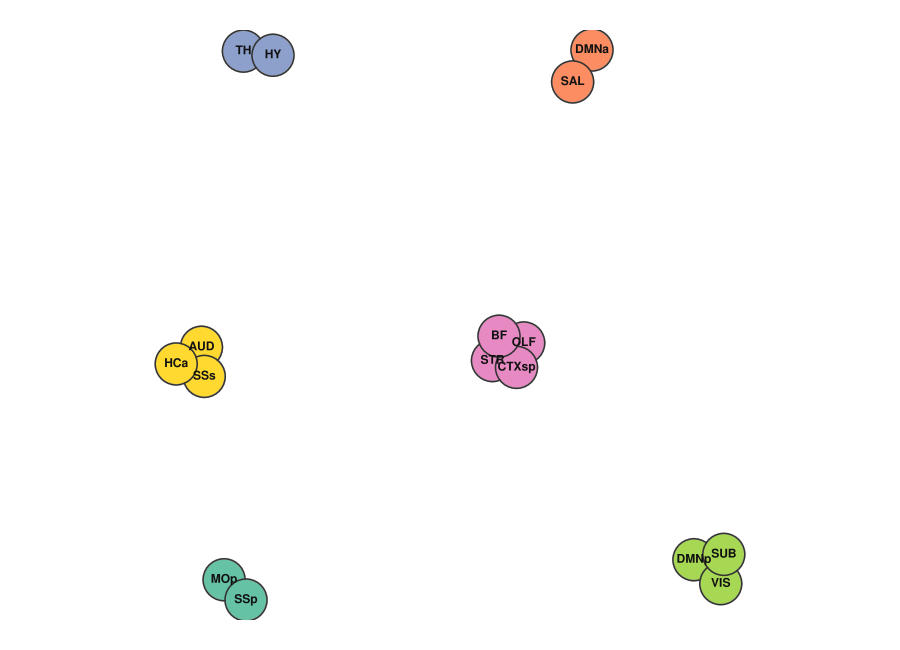

In [10]:
palette = toyplot.color.brewer.palette("Set2", count=CONSENSUS_COMMUNITIES)
vertex_colors = [palette[int(label) - 1] for label in consensus_labels]
edge_strength = np.asarray(edge_data["coassignment"], dtype=float)

canvas, axes, mark = toyplot.graph(
    edges,
    width=900,
    height=650,
    layout=toyplot.layout.FruchtermanReingold(seed=RANDOM_SEED),
    vlabel=roi_names,
    vcolor=vertex_colors,
    vsize=42,
    vstyle={"stroke": "#333333", "stroke-width": 1.5},
    vlstyle={"fill": "#111111", "font-size": "12px", "font-weight": "bold"},
    ecolor="#6b7280",
    eopacity=np.clip(0.15 + 0.85 * edge_strength, 0.2, 1.0),
    ewidth=0.5 + 5.0 * edge_strength,
)
axes.show = False
toyplot.svg.render(canvas, str(OUTPUT_DIR / "consensus_communities.svg"))
canvas

## How to interpret the output

- Do not interpret the numerical community IDs themselves; they are arbitrary.
- Inspect `consensus_vs_expected.csv` for the ROI composition and Jaccard overlap with the expected networks.
- Inspect `roi_coassignment.csv` to see how consistently each ROI pair clusters together across all runs and windows.
- Strong biological support requires similar consensus groups across multiple animals, experimental conditions, and nearby parameter values. This notebook analyzes one scan and is therefore a diagnostic example, not a group-level validation.